# Dengue: casos notificados por estado e por mês

**Pergunta que este notebook responde:** quantos casos de dengue foram
notificados no Brasil no ano, como se distribuem entre os estados e como
evoluíram mês a mês?

**Fonte:** SINAN — Sistema de Informação de Agravos de Notificação, agravo
`DENG`. Os dados são **nacionais** (o SINAN não é separado por estado).
**Tempo estimado:** 5 a 8 minutos, a maior parte em download.

> ⚠️ **Esta é a maior base do repositório.** O arquivo de 2024 tem
> **6,5 milhões de linhas e 121 colunas**. Carregá-lo inteiro consome cerca de
> **29 GB de memória** e trava o Google Colab. Este notebook mostra como
> trabalhar com ele usando menos de 1,5 GB — lendo apenas as colunas
> necessárias.

## Preparação

In [2]:
%pip install pysus nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
AGRAVO = "DENG"   # DENG, CHIK, ZIKA, TUBE, HANS, LEPT, MALA, VIOL...
ANO = 2024

## Passo 1 — Conferir se o ano existe

In [4]:
from pysus import list_files

catalogo = list_files(dataset="sinan", year=ANO)
agravos = sorted({nome.split("\\")[-1][:4] for nome in catalogo["name"]})

print(f"Agravos com dados em {ANO}: {len(agravos)}")
print(f"'{AGRAVO}' disponível? {'sim' if AGRAVO in agravos else 'NÃO'}")

Agravos com dados em 2024: 56
'DENG' disponível? sim


## Passo 2 — Baixar sem carregar na memória

Aqui está a diferença. Usamos `as_dataframe=False`: em vez de montar a tabela
inteira na memória, a biblioteca baixa o arquivo e devolve **o caminho** dele.
Assim decidimos depois o que carregar.

In [5]:
from pysus import sinan

caminhos = sinan(disease=AGRAVO, year=ANO, as_dataframe=False)

arquivo = caminhos[0]
print("Arquivo baixado:")
print(" ", arquivo)

Arquivo baixado:
  C:\Users\Alexandre\pysus\downloads\ducklake\sinan\DENGBR24.parquet


## Passo 3 — Ler apenas as colunas necessárias

O arquivo está em formato **Parquet**, que permite ler colunas isoladas sem
tocar no resto. Para esta análise precisamos de apenas três das 121 colunas:

| Coluna | Significado |
|---|---|
| `DT_NOTIFIC` | Data da notificação |
| `SG_UF_NOT` | Código do estado onde foi notificado |
| `CLASSI_FIN` | Classificação final do caso |

In [6]:
import pandas as pd

COLUNAS = ["DT_NOTIFIC", "SG_UF_NOT", "CLASSI_FIN"]

casos = pd.read_parquet(arquivo, columns=COLUNAS)

print(f"{len(casos):,} notificações carregadas")
print(f"Memória usada: {casos.memory_usage(deep=True).sum() / 1e9:.2f} GB "
      f"(seriam ~29 GB com todas as colunas)")
casos.head()

6,564,924 notificações carregadas


Memória usada: 1.06 GB (seriam ~29 GB com todas as colunas)


,DT_NOTIFIC,SG_UF_NOT,CLASSI_FIN
0,2024-03-04,32,10
1,2024-04-17,32,10
2,2024-06-22,32,10
3,2023-12-31,32,11
4,2023-12-31,32,10


## Passo 4 — Casos por estado

O DATASUS identifica o estado por um **código numérico** do IBGE, não pela
sigla. A tabela abaixo faz a tradução.

In [7]:
UFS = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA", "16": "AP", "17": "TO",
    "21": "MA", "22": "PI", "23": "CE", "24": "RN", "25": "PB", "26": "PE", "27": "AL",
    "28": "SE", "29": "BA", "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS", "50": "MS", "51": "MT", "52": "GO", "53": "DF",
}

por_uf = (
    casos["SG_UF_NOT"].astype(str).map(UFS)
    .value_counts()
    .rename_axis("UF")
    .reset_index(name="Notificações")
)

print(f"Total no Brasil: {por_uf['Notificações'].sum():,} notificações")
por_uf.head(10)

Total no Brasil: 6,564,924 notificações


,UF,Notificações
0,SP,2182413
1,MG,1658372
2,PR,647663
3,SC,336334
4,GO,334182
5,RJ,302190
6,DF,279020
7,BA,231942
8,RS,224791
9,ES,137871


## Passo 5 — Os dez estados com mais notificações

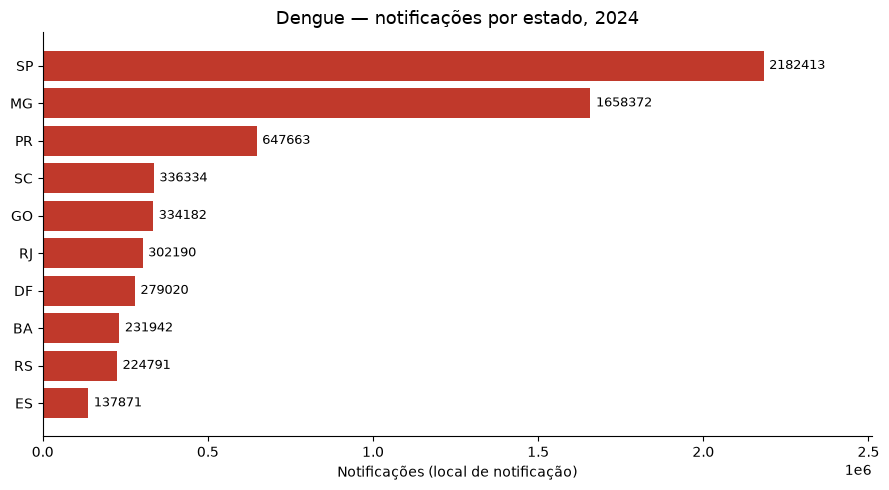

In [8]:
import matplotlib.pyplot as plt

top10 = por_uf.head(10).sort_values("Notificações")

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(top10["UF"], top10["Notificações"], color="#c0392b")
ax.bar_label(barras, fmt="%,.0f".replace(",", ""), padding=4, fontsize=9)

ax.set_title(f"Dengue — notificações por estado, {ANO}", fontsize=13)
ax.set_xlabel("Notificações (local de notificação)")
ax.set_xlim(0, top10["Notificações"].max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Passo 6 — A curva do ano

A distribuição mês a mês é o formato clássico de acompanhamento de arboviroses.

In [9]:
casos["data"] = pd.to_datetime(casos["DT_NOTIFIC"], errors="coerce")

por_mes = (
    casos.dropna(subset=["data"])
    .groupby(casos["data"].dt.to_period("M"))
    .size()
)
por_mes = por_mes[por_mes.index.year == ANO]

print("Notificações por mês:")
for periodo, quantidade in por_mes.items():
    print(f"  {periodo}: {quantidade:>9,}")

Notificações por mês:
  2024-01:   339,190
  2024-02:   996,680
  2024-03: 1,623,904
  2024-04: 1,700,759
  2024-05: 1,178,021
  2024-06:   361,635
  2024-07:   120,308
  2024-08:    57,082
  2024-09:    37,800
  2024-10:    35,542
  2024-11:    44,605
  2024-12:    68,637


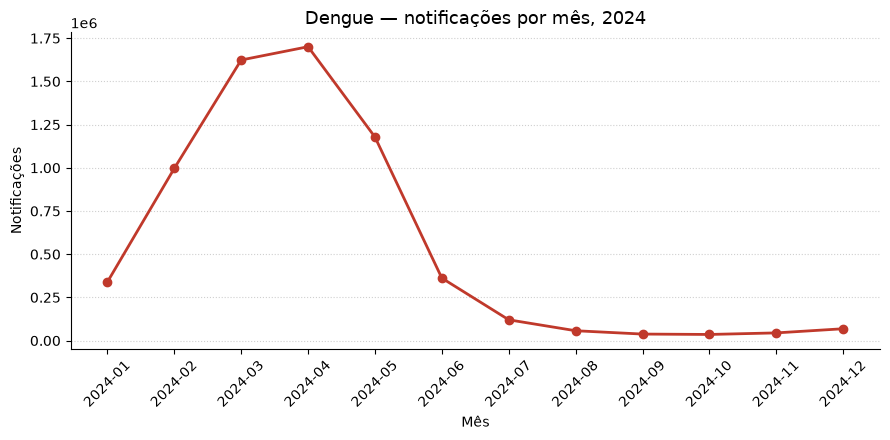

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot([str(p) for p in por_mes.index], por_mes.values,
        marker="o", color="#c0392b", linewidth=2)

ax.set_title(f"Dengue — notificações por mês, {ANO}", fontsize=13)
ax.set_ylabel("Notificações")
ax.set_xlabel("Mês")
ax.grid(axis="y", linestyle=":", alpha=.6)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Sobre a leitura destes números

- São **notificações**, não casos confirmados. A coluna `CLASSI_FIN` traz a
  classificação final (confirmado, descartado, inconclusivo) e pode ser usada
  para filtrar.
- `SG_UF_NOT` é o estado **onde a notificação foi registrada**, que nem sempre
  é o de residência do paciente (para isso existe `SG_UF`).
- Os dados são revisados continuamente pelas secretarias: um mesmo ano
  consultado em datas diferentes pode trazer totais um pouco diferentes.
- Para comparar estados de forma justa, é preciso calcular a **incidência por
  100 mil habitantes**, usando a população do IBGE.

## Como adaptar

- **Outra doença:** troque `AGRAVO` por `CHIK` (chikungunya), `ZIKA`, `LEPT`
  (leptospirose), `TUBE` (tuberculose), `HANS` (hanseníase), `VIOL`
  (violência)… O notebook `_comece-aqui/02` lista todos os disponíveis.
- **Só casos confirmados:** filtre `CLASSI_FIN` antes de contar.
- **Um estado só:** filtre `SG_UF_NOT` pelo código do seu estado logo após a
  leitura — o resto do notebook continua igual.

---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*